<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/decision_tree_classification/lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

In this part of the project, I import all the necessary Python libraries used for building, training, and evaluating a Decision Tree Classification model.
Each library provides a specific functionality essential for data analysis, visualization, and machine learning tasks.

NumPy (np) – used for performing efficient numerical operations, handling arrays, and matrix manipulations.

Matplotlib (plt) – a visualization library used to create plots and charts (such as accuracy graphs or tree diagrams).

Pandas (pd) – provides high-level data structures (DataFrames) for data analysis and manipulation, making it easy to clean, explore, and preprocess datasets.

scikit-learn (sklearn) – the main library for machine learning in Python. It offers tools for loading datasets, training models, and evaluating performance.

datasets and load_wine – used to load ready-to-use datasets such as the Wine dataset, commonly used for classification tasks.

DecisionTreeClassifier – the core model used to build a Decision Tree, which learns decision rules from the data to classify samples.

plot_tree – a visualization tool that draws the structure of the decision tree, showing nodes, splits, and decision thresholds.

train_test_split – divides the dataset into training and testing subsets to validate model performance.

GridSearchCV – performs hyperparameter tuning, automatically testing different parameter combinations to find the best-performing model.

accuracy_score – evaluates the model by measuring how many predictions were correct compared to the actual labels.

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

In this step, I load the Wine dataset, a classic built-in dataset from the scikit-learn library that is commonly used for testing and demonstrating classification algorithms like Decision Trees.

load_wine() – loads the Wine dataset as a structured object that contains both the features (inputs) and the target labels (outputs).
This dataset describes chemical properties of different wines grown in the same region of Italy but derived from three distinct cultivars (classes).

X = wine.data – extracts the feature matrix, which contains 13 continuous numerical variables for each wine sample (e.g., alcohol, magnesium, flavanoids, color intensity, etc.).
Each row in X represents one wine sample, and each column represents one chemical feature.

y = wine.target – extracts the target vector, which contains integer class labels (0, 1, or 2) corresponding to the three types of wine.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

In this step, I divide the Wine dataset into two parts — one for training the Decision Tree model and one for testing it.
This ensures that the model’s performance can be evaluated on new, unseen data, giving a more realistic measure of how well it generalizes.

train_test_split() – a function from scikit-learn that splits the dataset into random subsets.

Parameters:

*   X → the features (all chemical measurements of the wines).
*   y → the target labels (wine classes: 0, 1, 2).
*   test_size=0.2 → allocates 20% of the data for testing and the remaining 80% for training.
*   random_state=42 → ensures reproducibility, meaning that the same split occurs every time the code is run.

Outputs:

*   X_train, y_train → used to train the Decision Tree model.
*   X_test, y_test → used to evaluate the model’s accuracy and performance.

This split is a standard step in supervised learning workflows, helping to avoid overfitting and ensuring that the model is evaluated on truly unseen data.

In [4]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
y_pred_full = full_tree.predict(X_test)
full_tree_acc = accuracy_score(y_test, y_pred_full)
print(f"Unpruned Decision Tree Accuracy: {full_tree_acc:.4f}")

Unpruned Decision Tree Accuracy: 0.9444


In this section, I build, train, and evaluate a Decision Tree Classifier on the Wine dataset without applying any pruning or depth restrictions.
This means the tree can grow freely until all samples are perfectly classified in the training set, which often leads to very high training accuracy — but it may overfit the data.

DecisionTreeClassifier(random_state=42) – initializes a new Decision Tree model.

*   By default, no maximum depth or pruning parameters are set, so the tree will expand fully.
*   random_state=42 ensures reproducibility, so results remain consistent across runs.

full_tree.fit(X_train, y_train) – trains (or fits) the model using the training data.
The Decision Tree algorithm recursively splits the dataset into smaller subsets based on feature thresholds that best separate the wine classes.

y_pred_full = full_tree.predict(X_test) – uses the trained model to make predictions on the test data (X_test).

accuracy_score(y_test, y_pred_full) – computes the classification accuracy, measuring how many predictions match the true labels (y_test).
The result is stored in full_tree_acc.

print(f"Unpruned Decision Tree Accuracy: {full_tree_acc:.4f}") – prints the model’s accuracy, formatted to four decimal places.

In [5]:
pre_pruned_tree = DecisionTreeClassifier  (max_depth=5,
min_samples_split=10, min_samples_leaf=5, random_state=42)
pre_pruned_tree.fit(X_train, y_train)
y_pred_prepruned = pre_pruned_tree.predict(X_test)
pre_pruned_acc = accuracy_score(y_test, y_pred_prepruned)
print(f"Pre-Pruned Decision Tree Accuracy: {pre_pruned_acc:.4f}")

Pre-Pruned Decision Tree Accuracy: 0.9444


In this step, I build and evaluate a pre-pruned Decision Tree, which means the tree’s growth is limited by specific constraints during training to prevent overfitting.
By setting parameters that control how deep and complex the tree can grow, the model becomes simpler, more general, and better at handling unseen data.

DecisionTreeClassifier(...) – initializes the Decision Tree model with pruning parameters that restrict its size and complexity:

max_depth=5 – limits the tree to a maximum depth of 5 levels. This prevents the model from splitting too deeply and memorizing noise from the training data.

min_samples_split=10 – sets the minimum number of samples required to split an internal node. This ensures that splits only occur when there’s enough data to justify a decision.

min_samples_leaf=5 – requires each leaf node (final branch) to contain at least 5 samples, which reduces the chance of creating overly specific or tiny branches.

random_state=42 – guarantees reproducible results.

pre_pruned_tree.fit(X_train, y_train) – trains the pruned Decision Tree using the training data, following the limits defined above.

y_pred_prepruned = pre_pruned_tree.predict(X_test) – makes predictions on the unseen test data.

accuracy_score(y_test, y_pred_prepruned) – calculates how accurately the pre-pruned model predicts the test labels.

The accuracy value (pre_pruned_acc) is then printed in a formatted way for easy comparison with the unpruned model.

In [6]:
param_grid = {
'max_depth': [3, 5, 10, None],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 5, 10]
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_tree = grid_search.best_estimator_
y_pred_gridsearch = best_tree.predict(X_test)
gridsearch_acc = accuracy_score(y_test, y_pred_gridsearch)
print(f"Grid Search Decision Tree Accuracy: {gridsearch_acc:.4f} with params: {best_params}")

Grid Search Decision Tree Accuracy: 0.9444 with params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


This section performs hyperparameter tuning for the Decision Tree model using Grid Search with Cross-Validation.
The goal is to automatically find the best combination of parameters that maximizes model accuracy and improves generalization to new data.

In [7]:

ccp_alphas = full_tree.cost_complexity_pruning_path(X_train,
y_train)['ccp_alphas']
accuracies = []
for alpha in ccp_alphas:
  pruned_tree = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
accuracies.append(accuracy_score(y_test, y_pred_pruned))
best_alpha = ccp_alphas[np.argmax(accuracies)]
post_pruned_tree = DecisionTreeClassifier(random_state=42,
ccp_alpha=best_alpha)
post_pruned_tree.fit(X_train, y_train)
y_pred_postpruned = post_pruned_tree.predict(X_test)
post_pruned_acc = accuracy_score(y_test, y_pred_postpruned)
print(f"Post-Pruned Decision Tree Accuracy: {post_pruned_acc:.4f} (Best alpha: {best_alpha:.4f})")

Post-Pruned Decision Tree Accuracy: 0.9444 (Best alpha: 0.0000)


This section applies post-pruning to the Decision Tree using the cost-complexity pruning technique.
The goal is to simplify the fully grown (unpruned) tree by removing branches that contribute little to improving accuracy — making the model more general and preventing overfitting.

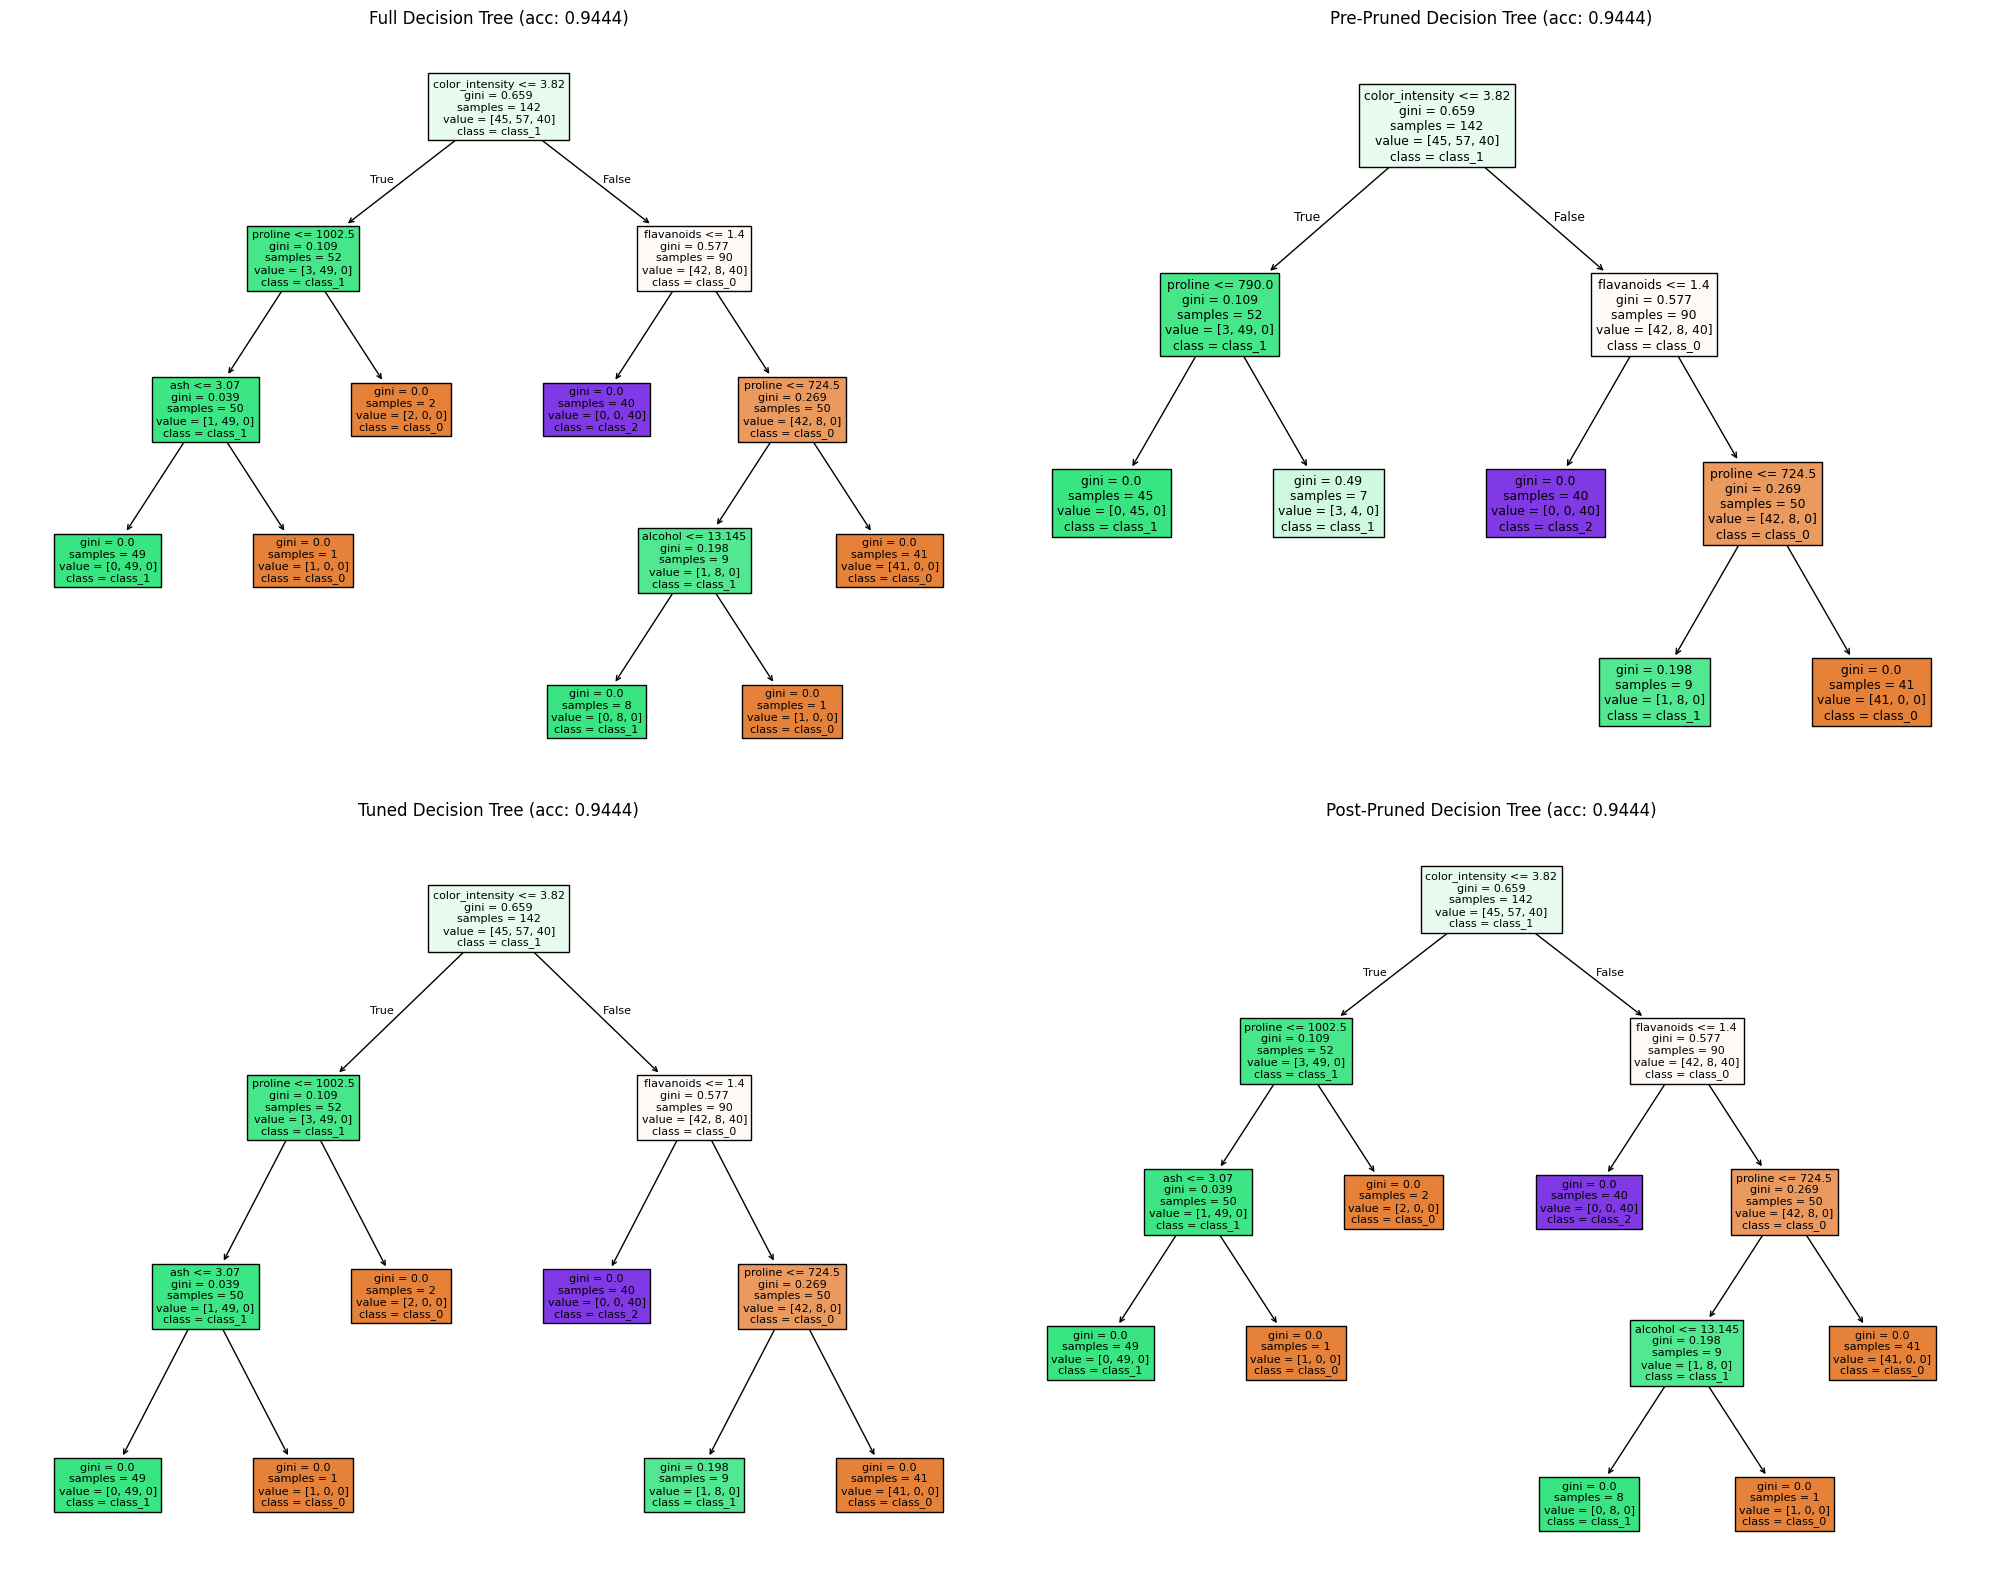

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))
plot_tree(full_tree, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, ax=axs[0, 0])
axs[0, 0].set_title(f"Full Decision Tree (acc: {full_tree_acc:.4f})")

plot_tree(pre_pruned_tree, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, ax=axs[0, 1])
axs[0, 1].set_title(f"Pre-Pruned Decision Tree (acc: {pre_pruned_acc:.4f})")

plot_tree(best_tree, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, ax=axs[1, 0])
axs[1, 0].set_title(f"Tuned Decision Tree (acc: {gridsearch_acc:.4f})")

plot_tree(post_pruned_tree, filled=True, feature_names=wine.feature_names, class_names=wine.target_names, ax=axs[1, 1])
axs[1, 1].set_title(f"Post-Pruned Decision Tree (acc: {post_pruned_acc:.4f})")

plt.tight_layout()
plt.show()

This section creates a comprehensive visualization that compares four versions of the Decision Tree classifier — from fully grown to optimized and pruned variants.
It allows for a clear visual understanding of how pruning and hyperparameter tuning affect the model’s structure and complexity.

In [10]:
wine_tree = DecisionTreeClassifier(criterion='entropy')
wine_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

Using the entropy-based Decision Tree allows for more interpretable splits that focus on information gain.
This model learns patterns from the training data that will later be tested on unseen samples to classify wines accurately into one of the three target classes.

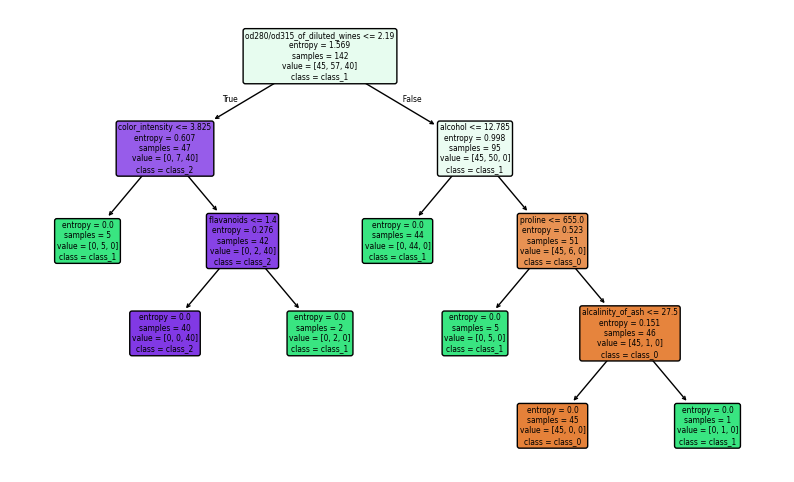

In [11]:
plt.figure(figsize=(10, 6))
plot_tree(wine_tree, feature_names=wine.feature_names, class_names=wine.target_names, filled=True, rounded=True)
plt.show()

In this step, I visualize the Decision Tree that was trained using the entropy criterion on the Wine dataset.
This visualization helps interpret how the model makes decisions and which features contribute most to classifying different types of wine.

In [12]:
accuracy_iris_tree = accuracy_score(y_test, wine_tree.predict(X_test))
print('Decision tree accuracy',accuracy_iris_tree)

Decision tree accuracy 0.9166666666666666


In this step, I evaluate how accurately the Decision Tree (entropy-based) model predicts the wine classes on the test dataset.

wine_tree.predict(X_test) – uses the trained Decision Tree model to make predictions on the unseen test features (X_test).
Each prediction corresponds to one of the three wine categories.

accuracy_score(y_test, wine_tree.predict(X_test)) – compares the predicted labels with the true labels (y_test) and calculates the accuracy of the model.
Accuracy represents the proportion of correct predictions out of the total number of samples:

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$
	​


The result is stored in accuracy_iris_tree, which holds the model’s accuracy score as a float (typically between 0.0 and 1.0).

print('Decision tree accuracy', accuracy_iris_tree) – displays the accuracy score in the output, giving a quick overview of how well the model performs.